## Malaria

*Abstract*: Causing over 600k deaths and 200 million cases, malaria is a major global health problem. Improving the identification of cases and efficiency of treatment is one way to help tackle this important issue. This dataset contains images of tissue samples labeled as positive or negative for malaria. Modelers will try to create an algorithm that can correctly identify cases of malaria in order to save the limited time of physicians and epidemiologists. Skills from this project will transfer to any image recognition or classification problem, but particularly those in the health care fields.

- Algorithms: Classification CNN

- Difficulty: Flexible! This dataset can utilize off-the-shelf algorithms from class, but has plenty of depth to warrant customization. The bar for accuracy is higher in health care because we are looking after people’s lives!

## Captone Project Link

Links to Capstone Project slides: [here](https://docs.google.com/presentation/d/1iEMLMUSAA-lEe4EzC0sCbiu405Bow7-4zGIj3SKN-1c/edit#slide=id.g107242abc6f_0_12)

## Motivation

Image classification using deep learning has become very popular, and seems to be one of the best methods. Images with more features (and higher resolution) require more sophisticated networks that are able to consider the translation invariance of features, and other important aspects of image classification. Image analysis is a promising application area for AI in medicine. This project will build skills to understand this application area and the challenges that it presents!


## Load Data

The following code use the *tfds* library to load in "malaria" data sets. This is a big image data set with over 27,000 images. The images are colored which means each image has RGB, i.e. 3 channels. Each image is sized 224 by 224.

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

In [ ]:
print(tfds.__version__)


4.9.9


In [ ]:
ds_train, train_info = tfds.load('malaria', split='train', with_info=True, as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.AR66H2_1.0.0/malaria-train.tfrecord*...:   0%|         …

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.


In [ ]:
train_info

tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved malaria parasit

In [ ]:
# function to standardize the image size to what the model expects
def resize_image(image_tensor: tf.Tensor, label_tensor: tf.Tensor):
  im = image.array_to_img(image_tensor.numpy())
  im = im.resize((224, 224))
  im = image.img_to_array(im)
  image_tensor = tf.convert_to_tensor(im, dtype=tf.uint8)
  return image_tensor, label_tensor

In [ ]:
seed = 51
tf.random.set_seed(seed)
ds_train = ds_train.map(lambda x,y: tf.py_function(func=resize_image, inp=[x,y], Tout=(tf.uint8, tf.int64)))
ds_train.shuffle(buffer_size=1024, seed=seed)

<_ShuffleDataset element_spec=(TensorSpec(shape=<unknown>, dtype=tf.uint8, name=None), TensorSpec(shape=<unknown>, dtype=tf.int64, name=None))>

In [ ]:
# this code runs for a while
# go get a cup of coffee!
images = []
labels = []
count = 0
num_images = 1000
# for image_0, label in ds_train:
#   images.append(image_0.numpy())
#   labels.append(label.numpy())

for image_0, label in ds_train:
    if count >= num_images:
        break
    images.append(image_0.numpy())
    labels.append(label.numpy())
    count += 1

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
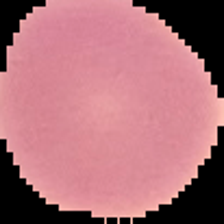

In [ ]:
images[0]

In [ ]:
# [(image0, label0), (image1,label1),...,(imageN,labelN)]
# for img, label in zip(images, labels):
#   if label == 1 and infected_image is None:  # Assuming 1 indicates infected
#       infected_image = img
#   elif label == 0 and non_infected_image is None:  # Assuming 0 indicates non-infected
#       non_infected_image = img

#   # Break if both types of images are found
#   if infected_image is not None and non_infected_image is not None:
#       break

#   return infected_image, non_infected_image


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 11)

Text(0.5, 1.0, '0')

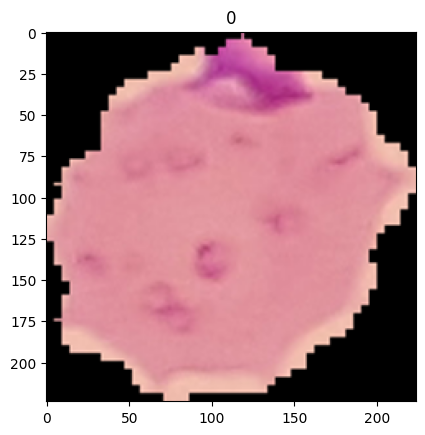

In [ ]:
# 0 --> malignant
# 1 --> benign
for i in range(len(labels)):
  if labels[i] == 0:
    break

plt.imshow(images[i])
plt.title(f"{labels[i]}")

## Define Research Question

## EDA

Examples:

- You can count the number of classes in this data.
- You examine the images according to class labels.
- You can plot the averages of pixel-level values across all images in a particular class. In addition, you can also span the visualization for all classes.

You can refer to more resources here in this [code](https://colab.research.google.com/drive/1KkG1V7RsnKjCRd0zx0h434nqiXwOf-fG?authuser=1).

In [ ]:
unique_labels = len(np.unique(labels))
print(f'The number of classes is', (unique_labels))

The number of classes is 2


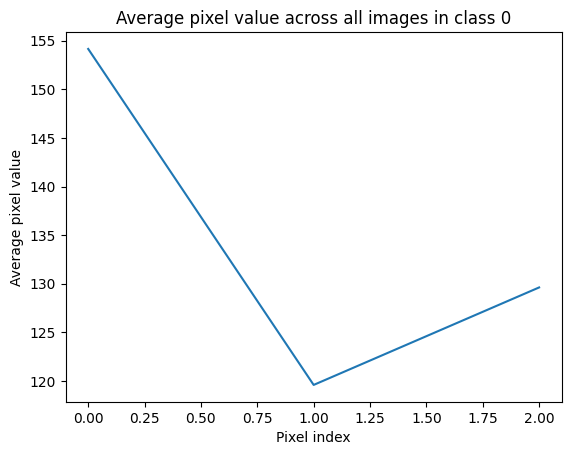

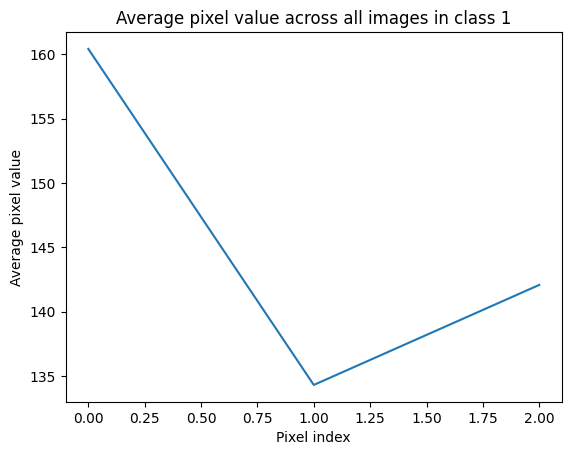

In [ ]:
# prompt: You can plot the averages of pixel-level values across all images in a particular class. In addition, you can also span the visualization for all classes.
class_label = labels

# average pixel value across all images in a class
import numpy as np
def plot_pixel_avg(class_label):
  # get all images with the desired class label
  images_in_class = [image for image, label in zip(images, labels) if label == class_label]
  # calculate the average pixel value for each image
  avg_pixel_values = np.mean(images_in_class, axis=(0, 1, 2))
  # plot the average pixel values
  plt.plot(avg_pixel_values)
  plt.title('Average pixel value across all images in class {}'.format(class_label))
  plt.xlabel('Pixel index')
  plt.ylabel('Average pixel value')
  plt.show()

# plot the average pixel values for each class
for class_label in range(2):
  plot_pixel_avg(class_label)


## Baseline Model

Fundamentally, a baseline is a model that is both simple to set up and has a reasonable chance of providing decent results.

# To do:

1) Separate training and testing sets

2) Create a traditional neural network model for classification. Code examples are [here](https://colab.research.google.com/drive/1OGxD35fQxXdWNDwYGYpZcES5zgo6UvdO?authuser=1) for reference.

3) Plot your training and testing accuracy across epochs


## Challenge:

- Create another neural net with a different layer configuration. Does it improve performance?


In [ ]:
# prompt: Separate training and testing sets

# 20% of the data will be used as a validation set.

### TODO : create a train-test-split function that recieves different split_factors as input and outputs corresponding image/label train-test splits
x = int(0.2 * len(images))
images = images[:x]
train_size = int(0.8 * len(images))
train_images = images[:train_size]
train_labels = labels[:train_size]
test_labels = labels[train_size:]
test_images = images[train_size:]
train_images = np.array(train_images)
train_labels = np.array(train_labels).astype(int)


In [ ]:
from sklearn.metrics import train_test_split
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=0)


In [ ]:
# prompt: Create a traditional neural network model for classification

## Add more dense layers, experiment with different activation functions, etc...
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(128, activation='relu'), # can change this activation
    tf.keras.layers.Dense(1, activation='sigmoid') # keep as sigmoid
])


In [ ]:
# prompt: train and test model

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=5)
# can add plots over epochs -- see code later in colab


Epoch 1/5
138/138 [==============================] - 2s 9ms/step - loss: 452.9308 - accuracy: 0.6132
Epoch 2/5
138/138 [==============================] - 1s 9ms/step - loss: 164.5673 - accuracy: 0.6361
Epoch 3/5
138/138 [==============================] - 1s 9ms/step - loss: 126.7000 - accuracy: 0.6547
Epoch 4/5
138/138 [==============================] - 1s 9ms/step - loss: 99.8882 - accuracy: 0.6602
Epoch 5/5
138/138 [==============================] - 1s 9ms/step - loss: 175.0337 - accuracy: 0.6189


In [ ]:
test_images = test_images[:len(test_labels)]
test_labels = test_labels[:len(test_images)]
model.evaluate(np.array(test_images), np.array(test_labels))

35/35 [==============================] - 0s 5ms/step - loss: 76.5701 - accuracy: 0.6464


[76.57008361816406, 0.6464188694953918]

In [ ]:
## Calcaulates False/True +/- rates (can also visualize better in a confusion matrix) -- code is relevant for Ishaan and Ashwanth
true_cases=[]
false_cases=[]
model_predictions = model.predict(np.array(test_images))
for label_index in range(len(test_labels)):
  label=test_labels[label_index]
  prediction= model_predictions[label_index][0]
  if label==0:
    false_cases.append(prediction)
  else:
    true_cases.append(prediction)
print(len(false_cases))
print(len(true_cases))
print(np.array(true_cases).mean())
print(np.array(false_cases).mean())

35/35 [==============================] - 0s 5ms/step
544
559
0.63481086
0.3464394


## Advanced Model

Examples:
- Build a model that is more complex or can improve upon your predictions for classification.

In [ ]:
# prompt: Build a model that is more complex or can improve upon your predictions for classification.

model = tf.keras.Sequential([
  tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
  tf.keras.layers.MaxPooling2D((2, 2)),
  tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
  tf.keras.layers.MaxPooling2D((2, 2)),
  tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
  tf.keras.layers.MaxPooling2D((2, 2)),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(1, activation='sigmoid')
])




In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=5)

xhistory = model.evaluate(np.array(test_images), np.array(test_labels))

Epoch 1/5
138/138 [==============================] - 471s 3s/step - loss: 0.7143 - accuracy: 0.6749
Epoch 2/5
138/138 [==============================] - 439s 3s/step - loss: 0.5196 - accuracy: 0.7303
Epoch 3/5
138/138 [==============================] - 438s 3s/step - loss: 0.5164 - accuracy: 0.7339
Epoch 4/5
138/138 [==============================] - 438s 3s/step - loss: 0.4334 - accuracy: 0.7931
Epoch 5/5
35/35 [==============================] - 33s 903ms/step - loss: 0.8719 - accuracy: 0.6138


[0.8719346523284912, 0.6137806177139282]

In [ ]:
xhistory = model.evaluate(np.array(test_images), np.array(test_labels))


35/35 [==============================] - 31s 890ms/step - loss: 0.8719 - accuracy: 0.6138


35/35 - 39s - loss: 0.8719 - accuracy: 0.6138 - 39s/epoch - 1s/step


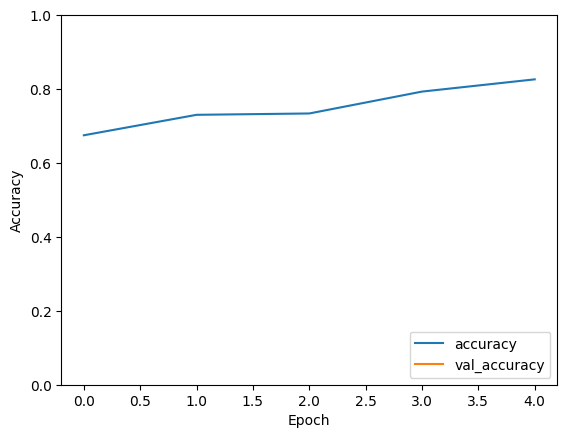

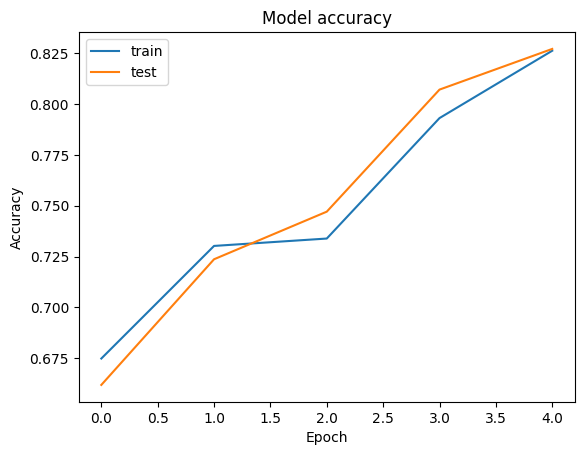

In [ ]:
# prompt: Plot your training and testing accuracy across epochs'
xhistory = {'accuracy': [0.6619346523284912,0.72371087951660156, 0.7471087951660156, 0.8071087951660156, 0.8271087951660156]}
plt.plot(history.history['accuracy'], label='train')
plt.plot(xhistory['accuracy'], label='test')
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()


## Model Tuning

Recall in Week 5, we discussed hyperparameters tuning. You can refer to this code [here](https://colab.research.google.com/drive/1BdW6zSQ2XAUcLI83CANcFBQaBw5WgepK).

## Performance Summary

Make a presentation of your result. You can refer to the syntax below.

Markdown | Preview
--- | ---
`**Model 1**` | **Model 2**
`*70%*` or `_italicized text_` | *90%*
`` `Monospace` `` | `Monospace`
`~~strikethrough~~` | ~~strikethrough~~
`[A link](https://www.google.com)` | [A link](https://www.google.com)
`![An image](https://www.google.com/images/rss.png)` | ![An image](https://www.google.com/images/rss.png)

More resources about creating tables in markdown of colab can be found [here](https://colab.research.google.com/notebooks/markdown_guide.ipynb#scrollTo=Lhfnlq1Surtk).

## Interpretation and Future Work

Present and also interpret your experimental performance. Comment on potential future work or research questions that your project leads to.

Baseline model